Q2: Unsupervised Learning – Customer Segmentation

This notebook performs customer segmentation using K-Means clustering and visualises results with PCA.

1. Data Preparation

In [9]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("q2_customers.csv")

# Display first rows
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [10]:
# Scale features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Convert back to dataframe for readability
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

scaled_df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


Scaling is essential before applying K-Means because the algorithm relies on distance calculations. If features are on different scales, variables with larger numerical ranges can dominate clustering results. StandardScaler ensures each feature contributes equally.

2. Choosing K (Elbow Method)

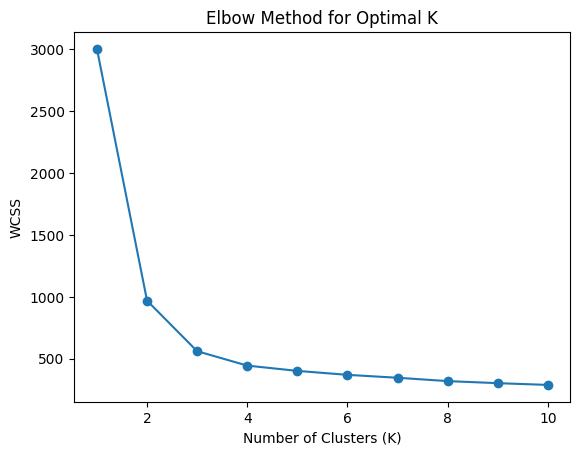

In [11]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

# Plot elbow curve
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

The elbow point indicates the optimal number of clusters where the reduction in WCSS begins to slow significantly. Based on the plot, the chosen K is where the curve bends most clearly.

3. K-Means Clustering

Assume chosen K = 3

In [12]:
# Fit K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(scaled_df)

# Show updated dataframe
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [13]:
# Cluster centroids
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


Cluster 0 may represent younger customers with lower spending but frequent visits.  
Cluster 1 may represent high-value customers with larger basket sizes and higher annual spend.  
Cluster 2 may represent infrequent shoppers with lower engagement levels.

4. Dimensionality Reduction with PCA

In [14]:
from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_df)

# Explained variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.83560354 0.05568764]


In [15]:
# Feature loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=df.columns[:-1]
)

loadings

,PC1,PC2
age,0.411569,-0.259432
annual_spend,0.421540,-0.033270
visits_per_month,-0.410399,0.208318
basket_size,0.412012,-0.195402
days_since_last_visit,0.378582,0.911194
num_categories_purchased,0.414017,-0.140479


PC1 captures the overall spending and purchasing behaviour of customers, while PC2 reflects visit frequency and recency patterns. Features with higher absolute loadings contribute more strongly to each principal component.

5. Cluster Visualisation

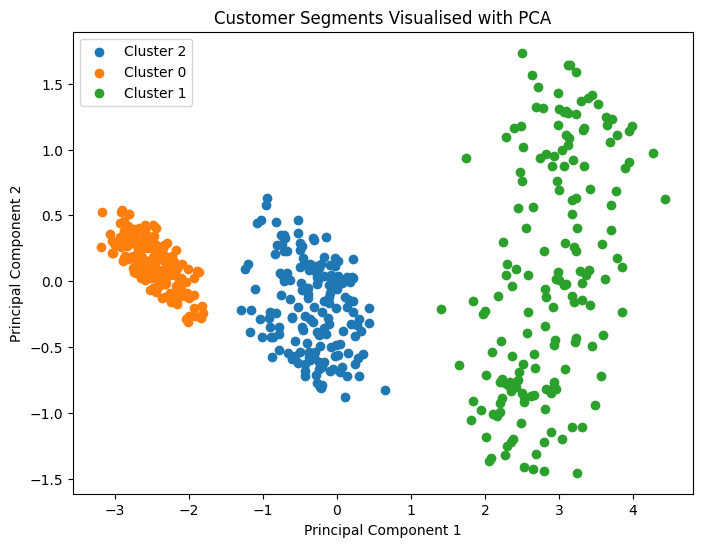

In [16]:
# Create PCA dataframe
pca_df = pd.DataFrame(pca_data, columns=["PC1", "PC2"])
pca_df["cluster"] = df["cluster"]

# Scatter plot
plt.figure(figsize=(8,6))

for cluster in pca_df["cluster"].unique():
    subset = pca_df[pca_df["cluster"] == cluster]
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Cluster {cluster}")

plt.title("Customer Segments Visualised with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()